--- ANTRENARE ISOLATION FOREST PE DATELE eBPF ---
Date partajate cu succes: Train_Normal=25980, Test_Total=13559
Antrenare Isolation Forest...
Antrenare finalizată în 0.42 secunde!

RAPORT METRICI:
              precision    recall  f1-score   support

      Normal       0.99      0.85      0.92     11161
        Atac       0.59      0.98      0.74      2398

    accuracy                           0.88     13559
   macro avg       0.79      0.92      0.83     13559
weighted avg       0.92      0.88      0.89     13559

Scor AUC: 0.9502


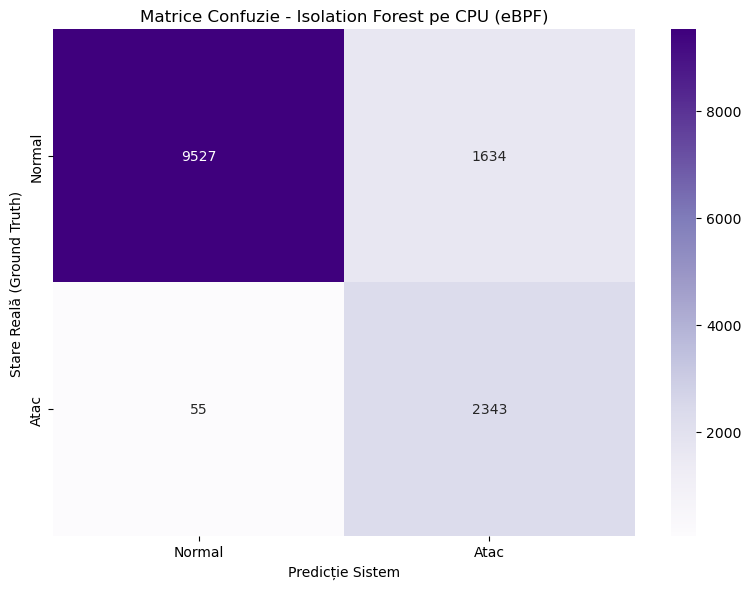

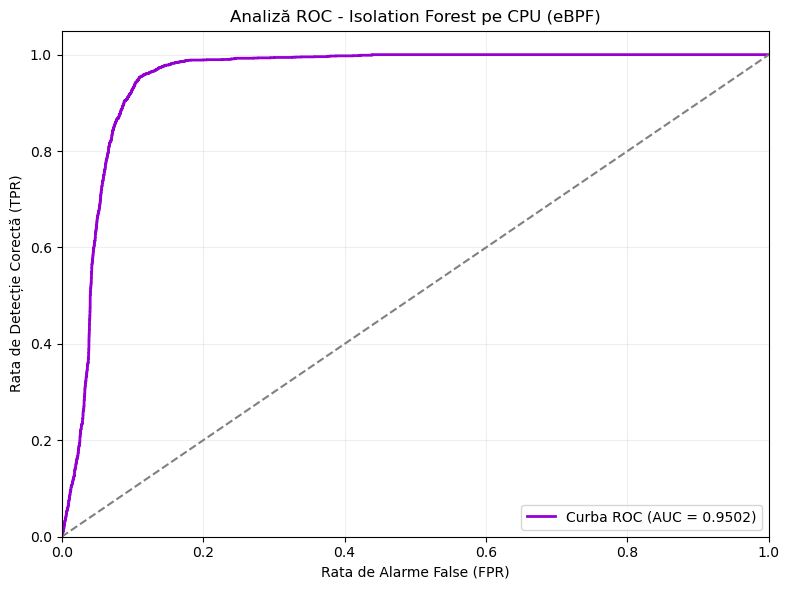


Toate rezultatele și graficele au fost salvate în: D:\disertatie\eBPF_WSL\rezultate_eBPF\Isolation_Forest


In [2]:
import pandas as pd
import numpy as np
import os
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

dataset_path = 'dataset_eBPF.csv'
rezultate_path = r'D:\disertatie\eBPF_WSL\rezultate_eBPF\Isolation_Forest'
os.makedirs(rezultate_path, exist_ok=True)

print("--- ANTRENARE ISOLATION FOREST PE DATELE eBPF ---")
df = pd.read_csv(dataset_path)

X_raw = df[['pid', 'uid', 'gid', 'len', 'hour']].values
y = df['label'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

rng = np.random.default_rng(42)
X_clean = X_scaled + rng.normal(0, 1e-5, size=X_scaled.shape)

indices = np.arange(len(df))
np.random.seed(42)
np.random.shuffle(indices)

split_idx = int(len(df) * 0.7)
train_indices = indices[:split_idx]
test_indices = indices[split_idx:]

X_train = X_clean[train_indices][y[train_indices] == 0]
X_test = X_clean[test_indices]
y_test = y[test_indices]

print(f"Date partajate cu succes: Train_Normal={len(X_train)}, Test_Total={len(X_test)}")

iso_forest = IsolationForest(n_estimators=200, contamination=0.15, random_state=42, n_jobs=-1)

start_time = time.time()
print("Antrenare Isolation Forest...")
iso_forest.fit(X_train)
train_time = time.time() - start_time
print(f"Antrenare finalizată în {train_time:.2f} secunde!")

decision_scores = iso_forest.decision_function(X_test)
y_pred_raw = iso_forest.predict(X_test)
y_pred = np.where(y_pred_raw == -1, 1, 0)

y_scores = -decision_scores
fpr, tpr, _ = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

report = classification_report(y_test, y_pred, target_names=['Normal', 'Atac'])
print("\nRAPORT METRICI:")
print(report)
print(f"Scor AUC: {roc_auc:.4f}")

with open(os.path.join(rezultate_path, 'raport_ebpf_iso_forest_cpu.txt'), 'w') as f:
    f.write(f"REZULTATE EBPF ISOLATION FOREST\nAUC: {roc_auc:.4f}\nTimp Antrenare: {train_time:.2f}s\n\n{report}")

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=['Normal', 'Atac'], yticklabels=['Normal', 'Atac'])
plt.title('Matrice Confuzie - Isolation Forest pe CPU (eBPF)')
plt.ylabel('Stare Reală (Ground Truth)')
plt.xlabel('Predicție Sistem')
plt.tight_layout()
plt.savefig(os.path.join(rezultate_path, 'matrice_confuzie_ebpf_cpu.png'), dpi=300)
plt.show()

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkviolet', lw=2, label=f'Curba ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.ylabel('Rata de Detecție Corectă (TPR)')
plt.xlabel('Rata de Alarme False (FPR)')
plt.title('Analiză ROC - Isolation Forest pe CPU (eBPF)')
plt.legend(loc="lower right")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(os.path.join(rezultate_path, 'curba_roc_ebpf_cpu.png'), dpi=300)
plt.show()

print(f"\nToate rezultatele și graficele au fost salvate în: {rezultate_path}")